# Bisection Method
> **Numerical Methods for Engineering** | Module 01 - Root Finding | `01_Bisection.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/01-Root-Finding/01_Bisection.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- State the **Intermediate Value Theorem** and understand why it guarantees a root.
- Derive the **a priori error bound** $|c_k - r| \leq (b-a)/2^k$ from first principles.
- Implement the Bisection algorithm in Python with full iteration tracking.
- Apply the method to problems in **general mathematics**, **chemistry**, and **telecommunications**.
- Decide when Bisection is appropriate and when to prefer faster alternatives.


In [14]:
import sys
!{sys.executable} -m pip install numpy matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, erfinv
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (11, 5), 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.35, 'lines.linewidth': 2,
})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 Motivation

Most engineering equations $f(x) = 0$ lack closed-form solutions. The Bisection method provides a
**guaranteed, systematic** strategy whenever we can bracket the root: find $a$ and $b$ such that
$f(a)$ and $f(b)$ have opposite signs.

---

### 1.2 The Intermediate Value Theorem (IVT)

**Theorem** *(Bolzano, 1817)*: Let $f$ be **continuous** on $[a,b]$. If

$$f(a)\cdot f(b) < 0,$$

then $\exists\; r\in(a,b)$ such that $f(r)=0$.

> **Geometric intuition:** a continuous curve starting below the $x$-axis and ending above it
> *must* cross it at least once.

---

### 1.3 Algorithm

1. Compute the midpoint $c = (a + b)/2$.
2. Evaluate $f(c)$.
3. If $f(a)\cdot f(c) < 0$, set $b \leftarrow c$; otherwise set $a \leftarrow c$.
4. Repeat until convergence.

---

### 1.4 Convergence Analysis and Error Bound

Each iteration **halves** the interval:

$$|b_k - a_k| = \frac{b_0 - a_0}{2^k}.$$

Since the root always lies in $[a_k, b_k]$ and $c_k$ is the midpoint:

$$\boxed{|c_k - r| \leq \frac{b_0 - a_0}{2^{k+1}}}$$

This is **linear convergence** (order $p=1$, rate $C=1/2$).

**Minimum iterations** for tolerance $\varepsilon$:

$$n \geq \left\lceil \log_2\!\left(\frac{b_0 - a_0}{\varepsilon}\right) \right\rceil$$

> **Proof sketch:** $|e_k| < \varepsilon \Leftrightarrow 2^{k+1} > (b_0-a_0)/\varepsilon
> \Leftrightarrow k > \log_2((b_0-a_0)/\varepsilon) - 1$. $\square$

---

### 1.5 Stopping Criteria

| Criterion | Formula | Notes |
|-----------|---------|-------|
| Interval width | $\|b - a\| < \varepsilon$ | Guarantees absolute error bound |
| Function value | $\|f(c)\| < \delta$ | Useful near flat roots |
| Relative error | $\|c_\text{new}-c_\text{old}\|/\|c_\text{new}\| < \varepsilon_r$ | Scale-invariant |

---

### 1.6 Pseudocode

```
INPUT:  f, a, b, tol, max_iter
ENSURE: f(a)*f(b) < 0

FOR i = 1 TO max_iter:
    c  <-  (a + b) / 2
    IF  |b - a| / 2  <  tol   OR   f(c) = 0:
        RETURN c
    IF  f(a)*f(c) < 0:
        b <- c
    ELSE:
        a <- c
END FOR
RETURN c
```

---

### 1.7 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| Always converges when IVT holds | Requires valid bracketing interval |
| Simple - no derivative needed | Slow: **linear** convergence only |
| Predictable, provable error bound | One root per interval; misses even-multiplicity roots |
| Robust to ill-conditioned functions | Cannot exploit smoothness |


In [16]:
def bisection(f, a, b, tol=1e-8, max_iter=100, verbose=False):
    # Bisection Method: find root of f on [a, b].
    # Returns (root, history_dict).
    if f(a) * f(b) >= 0:
        raise ValueError(
            f'IVT not satisfied: f({a:.4g})={f(a):.4g}, f({b:.4g})={f(b):.4g}'
        )
    hist = {'midpoints': [], 'errors': [], 'f_values': []}
    if verbose:
        print(f"{'n':>4}  {'a':>14}  {'b':>14}  {'c':>14}  {'f(c)':>12}  {'|err|':>12}")
        print('-' * 80)
    c = (a + b) / 2.0
    for i in range(1, max_iter + 1):
        c = (a + b) / 2.0
        err = (b - a) / 2.0
        fc  = f(c)
        hist['midpoints'].append(c)
        hist['errors'].append(err)
        hist['f_values'].append(fc)
        if verbose:
            print(f'{i:>4}  {a:>14.8f}  {b:>14.8f}  {c:>14.8f}  {fc:>12.4e}  {err:>12.4e}')
        if err < tol or fc == 0.0:
            break
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    return c, hist


def error_bound(a0, b0, n):
    # Theoretical upper bound (b0-a0)/2^k for k=1..n
    return (b0 - a0) / 2.0 ** np.arange(1, n + 1)

---
## 2. Examples

### 2.1 General Mathematical Example

Find the real root of $f(x) = x^3 - x - 2$.

**Bracketing:** $f(1) = -2 < 0$ and $f(2) = 4 > 0$ -- IVT holds on $[1, 2]$.

**Exact root:** $x^* \approx 1.52137970680\ldots$ (only real root, verified by Cardano's formula).


   n               a               b               c          f(c)         |err|
--------------------------------------------------------------------------------
   1      1.00000000      2.00000000      1.50000000   -1.2500e-01    5.0000e-01
   2      1.50000000      2.00000000      1.75000000    1.6094e+00    2.5000e-01
   3      1.50000000      1.75000000      1.62500000    6.6602e-01    1.2500e-01
   4      1.50000000      1.62500000      1.56250000    2.5220e-01    6.2500e-02
   5      1.50000000      1.56250000      1.53125000    5.9113e-02    3.1250e-02
   6      1.50000000      1.53125000      1.51562500   -3.4054e-02    1.5625e-02
   7      1.51562500      1.53125000      1.52343750    1.2250e-02    7.8125e-03
   8      1.51562500      1.52343750      1.51953125   -1.0971e-02    3.9062e-03
   9      1.51953125      1.52343750      1.52148438    6.2218e-04    1.9531e-03
  10      1.51953125      1.52148438      1.52050781   -5.1789e-03    9.7656e-04
  11      1.52050781      1.

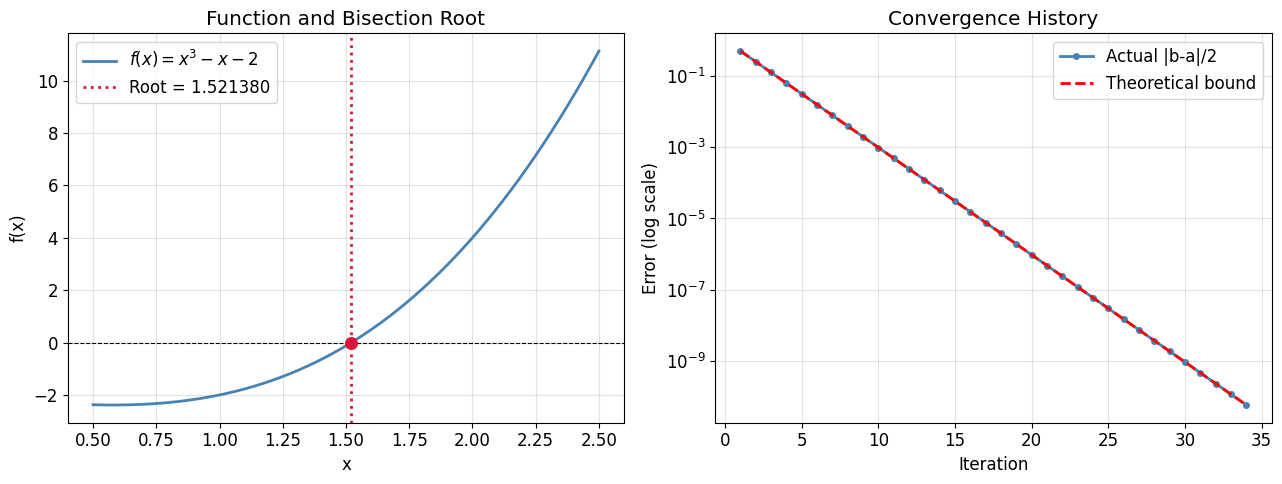

In [18]:
f1      = lambda x: x**3 - x - 2
x_star1 = 1.5213797068045675   # high-precision reference

root1, h1 = bisection(f1, 1.0, 2.0, tol=1e-10, verbose=True)

print(f'\nApproximate root : {root1:.12f}')
print(f'Exact root       : {x_star1:.12f}')
print(f'Absolute error   : {abs(root1 - x_star1):.2e}')
print(f'Iterations used  : {len(h1["midpoints"])}')

# --- Plots ---
x = np.linspace(0.5, 2.5, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x, f1(x), color='steelblue', label=r'$f(x)=x^3-x-2$')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(root1, color='crimson', ls=':', lw=2, label=f'Root = {root1:.6f}')
ax.scatter([root1], [0], color='crimson', zorder=5, s=70)
ax.set(xlabel='x', ylabel='f(x)', title='Function and Bisection Root'); ax.legend()

ax = axes[1]
n = len(h1['errors'])
bound = error_bound(1.0, 2.0, n)
ax.semilogy(range(1, n+1), h1['errors'], 'o-', color='steelblue', ms=4, label='Actual |b-a|/2')
ax.semilogy(range(1, n+1), bound, 'r--', label='Theoretical bound')
ax.set(xlabel='Iteration', ylabel='Error (log scale)', title='Convergence History'); ax.legend()

plt.tight_layout()
plt.show()

### 2.2 Chemistry Application - Weak Acid Dissociation

**Background:** For a weak acid HA with dissociation constant $K_a$ and initial concentration $C$:

$$\text{HA} \rightleftharpoons \text{H}^+ + \text{A}^-$$

Setting $x = [\text{H}^+] = [\text{A}^-]$ and applying the equilibrium expression with mass balance:

$$K_a = \frac{x^2}{C - x} \implies \boxed{f(x) = x^2 + K_a x - K_a C = 0}$$

**IVT check:** $f(0) = -K_a C < 0$ and $f(C) = C^2 > 0$ ✔

**Analytical reference (quadratic formula):**

$$x^* = \frac{-K_a + \sqrt{K_a^2 + 4K_aC}}{2}$$

**Case study:** Acetic acid (CH3COOH), $K_a = 1.8 \times 10^{-5}$ mol/L, $C = 0.10$ mol/L.


  [H+] analytical : 1.33267097e-03 mol/L
  [H+] bisection  : 1.33267097e-03 mol/L
  Absolute error  : 2.74e-13
  pH analytical   : 2.87528
  pH numerical    : 2.87528
  Iterations      : 37


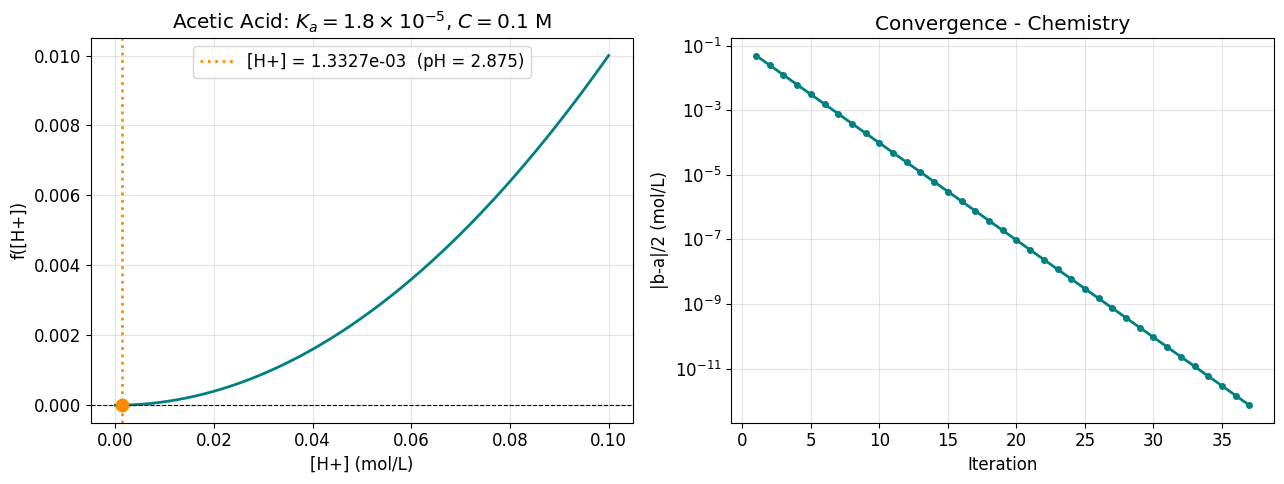

In [19]:
Ka = 1.8e-5    # acetic acid Ka  (mol/L)
C  = 0.10      # initial concentration (mol/L)

f2 = lambda x: x**2 + Ka * x - Ka * C

# Analytical reference
x_chem = (-Ka + np.sqrt(Ka**2 + 4 * Ka * C)) / 2

root2, h2 = bisection(f2, 0.0, C, tol=1e-12, verbose=False)

print('=' * 52)
print(f'  [H+] analytical : {x_chem:.8e} mol/L')
print(f'  [H+] bisection  : {root2:.8e} mol/L')
print(f'  Absolute error  : {abs(root2 - x_chem):.2e}')
print(f'  pH analytical   : {-np.log10(x_chem):.5f}')
print(f'  pH numerical    : {-np.log10(root2):.5f}')
print(f'  Iterations      : {len(h2["midpoints"])}')
print('=' * 52)

# --- Plots ---
xv = np.linspace(0, C, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(xv, f2(xv), color='teal')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(root2, color='darkorange', ls=':', lw=2,
           label=f'[H+] = {root2:.4e}  (pH = {-np.log10(root2):.3f})')
ax.scatter([root2], [0], color='darkorange', s=80, zorder=5)
ax.set(xlabel='[H+] (mol/L)', ylabel='f([H+])',
       title=r'Acetic Acid: $K_a=1.8\times10^{-5}$, $C=0.1$ M')
ax.legend()

ax = axes[1]
ax.semilogy(range(1, len(h2['errors'])+1), h2['errors'], 'o-', color='teal', ms=4)
ax.set(xlabel='Iteration', ylabel='|b-a|/2 (mol/L)', title='Convergence - Chemistry')

plt.tight_layout()
plt.show()

### 2.3 Telecommunications Application - Maximum Indoor WiFi Range

**Background:** In indoor environments, received power combines **Free-Space Path Loss (FSPL)**
with a linear excess attenuation term:

$$P_r(d)\;[\text{dBm}] = P_t + G_t + G_r
   - 20\log_{10}\!\left(\frac{4\pi d}{\lambda}\right)
   - \alpha\,d$$

Finding the **maximum range** $d^*$ where $P_r(d^*) = P_\text{th}$ leads to:

$$\boxed{f(d) = P_t + G_t + G_r - 20\log_{10}\!\left(\frac{4\pi d}{\lambda}\right) - \alpha d - P_\text{th} = 0}$$

This is **transcendental**: $d$ appears in both a **logarithm** and a **linear** term - no
closed-form solution exists.

| Parameter | Value | Description |
|-----------|-------|-------------|
| $f$ | 2.4 GHz | Carrier frequency (IEEE 802.11n) |
| $P_t$ | 20 dBm | Transmit power |
| $G_t$ | 3 dBi | Transmit antenna gain |
| $\alpha$ | 0.12 dB/m | Indoor excess attenuation coefficient |
| $P_\text{th}$ | -82 dBm | Receiver sensitivity |


f(1.0)   = +64.83 dBm
f(600.0) = -62.61 dBm  --> IVT holds

Max indoor WiFi range : 169.68 m
Pr at d*              : -82.0000 dBm  (threshold -82.0 dBm)
Iterations            : 30


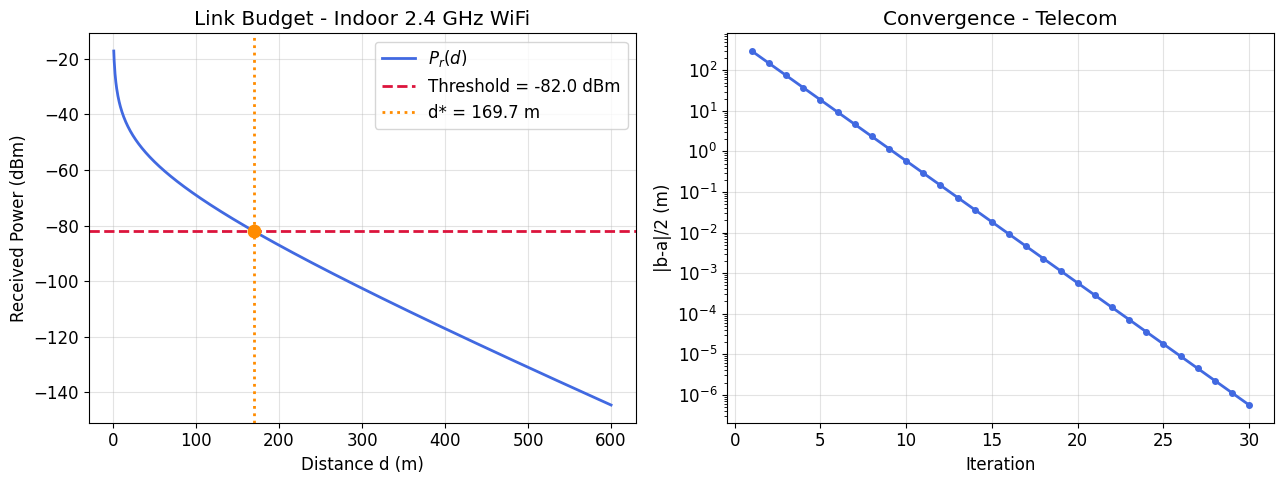

In [20]:
c_light = 3e8
freq    = 2.4e9
lam     = c_light / freq

Pt, Gt, Gr = 20.0, 3.0, 0.0
alpha  = 0.12    # dB/m (indoor attenuation)
P_th   = -82.0   # dBm  (receiver sensitivity)

def Pr(d):
    return Pt + Gt + Gr - 20*np.log10(4*np.pi*d/lam) - alpha*d

f3 = lambda d: Pr(d) - P_th

a3, b3 = 1.0, 600.0
print(f'f({a3})   = {f3(a3):+.2f} dBm')
print(f'f({b3}) = {f3(b3):+.2f} dBm  --> IVT holds')

root3, h3 = bisection(f3, a3, b3, tol=1e-6, verbose=False)
print(f'\nMax indoor WiFi range : {root3:.2f} m')
print(f'Pr at d*              : {Pr(root3):.4f} dBm  (threshold {P_th} dBm)')
print(f'Iterations            : {len(h3["midpoints"])}')

# --- Plots ---
d_vals = np.linspace(1, 600, 1200)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(d_vals, Pr(d_vals), color='royalblue', label=r'$P_r(d)$')
ax.axhline(P_th, color='crimson', ls='--', label=f'Threshold = {P_th} dBm')
ax.axvline(root3, color='darkorange', ls=':', lw=2, label=f'd* = {root3:.1f} m')
ax.scatter([root3], [P_th], color='darkorange', s=80, zorder=5)
ax.set(xlabel='Distance d (m)', ylabel='Received Power (dBm)',
       title='Link Budget - Indoor 2.4 GHz WiFi')
ax.legend()

ax = axes[1]
ax.semilogy(range(1, len(h3['errors'])+1), h3['errors'], 'o-', color='royalblue', ms=4)
ax.set(xlabel='Iteration', ylabel='|b-a|/2 (m)', title='Convergence - Telecom')

plt.tight_layout()
plt.show()

---
## 3. Convergence Summary

The number of iterations scales as $n \geq \lceil\log_2((b_0-a_0)/\varepsilon)\rceil$,
**independent of the function** - only the interval width and tolerance matter.


In [21]:
cases = [
    ('General math',          1.0,  2.0,   1e-10, h1),
    ('Chemistry (HA->H+)',     0.0,  0.10,  1e-12, h2),
    ('Telecom (WiFi range)',   1.0,  600.0, 1e-6,  h3),
]
print(f"{'Problem':<26} {'a0':>6} {'b0':>7} {'eps':>10} {'n_theory':>10} {'n_actual':>10}")
print('-' * 76)
for name, a0, b0, tol, h in cases:
    n_th = int(np.ceil(np.log2((b0 - a0) / tol)))
    n_ac = len(h['midpoints'])
    print(f'{name:<26} {a0:>6.3g} {b0:>7.3g} {tol:>10.1e} {n_th:>10d} {n_ac:>10d}')

Problem                        a0      b0        eps   n_theory   n_actual
----------------------------------------------------------------------------
General math                    1       2    1.0e-10         34         34
Chemistry (HA->H+)              0     0.1    1.0e-12         37         37
Telecom (WiFi range)            1     600    1.0e-06         30         30


---
## 4. Student Exercises

> Only problem statements are provided. Write your solution in the cells below.

---

**Exercise 1 - Multiple roots**
Find *all* real roots of $g(x) = e^x - 3x$ using Bisection with $\varepsilon = 10^{-7}$.
*Hint*: Plot $g$ on $[-1, 3]$ first to identify the bracketing intervals.

---

**Exercise 2 - Chemical solubility**
For calcium fluoride (CaF2): $K_{sp} = 4s^3$, $K_{sp} = 3.45\times10^{-11}$.
Find the molar solubility $s$ using Bisection. Verify with the analytical result
$s = (K_{sp}/4)^{1/3}$.

---

**Exercise 3 - Telecommunications**
A coaxial cable has an attenuation constant
$\alpha(f) = k_1 \sqrt{f} + k_2 f$ (dB/m), with $k_1 = 0.008$ and $k_2 = 2\times10^{-5}$.
Find the frequency (in GHz) at which $\alpha = 1.5$ dB/m using Bisection.

---

**Exercise 4 - Error analysis**
For the general example ($f(x)=x^3-x-2$ on $[1,2]$):
a) How many iterations are needed for $\varepsilon = 10^{-15}$?
b) Plot the **actual error** $|c_n - r|$ against the **theoretical bound** on a log-scale.
c) Does the actual error always stay below the bound? Explain.

---

**Exercise 5 - Regula Falsi**
Implement the **False Position** method, which replaces the midpoint with the $x$-intercept of
the secant line through $(a, f(a))$ and $(b, f(b))$:
$$c = b - f(b)\frac{b - a}{f(b) - f(a)}$$
Compare its convergence speed against Bisection on the acetic acid problem (Example 2.2).


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers* (7th ed., pp. 112-125).
   McGraw-Hill Education.
   *Primary textbook. Chapter 5 covers bracketing methods; Section 5.2 derives the Bisection error bound
   used in Section 1.4 of this notebook.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis* (10th ed., pp. 47-56).
   Cengage Learning.
   *Theorem 2.1 provides the formal proof of convergence reproduced in Section 1.4; rigorous treatment
   of stopping criteria in Section 1.5.*

3. **Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P.** (2007).
   *Numerical Recipes: The Art of Scientific Computing* (3rd ed., Section 9.1).
   Cambridge University Press.
   *Production-quality implementation notes, bracket-finding strategies, and combined stopping criteria.*

4. **Atkinson, K. E.** (1989). *An Introduction to Numerical Analysis* (2nd ed., pp. 55-61).
   John Wiley & Sons.
   *Classical graduate reference; Chapter 2 presents the a priori error analysis used in Section 1.4.*

5. **Goldsmith, A.** (2005). *Wireless Communications* (pp. 27-42). Cambridge University Press.
   *Source for the indoor path-loss propagation model used in Example 2.3. Chapter 2 details
   the log-distance and excess-attenuation models for IEEE 802.11 frequency bands.*
